In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from scipy.stats import chi2_contingency, fisher_exact, norm
import pingouin as pg
from scikit_posthocs import posthoc_dunn
from statsmodels.stats.multitest import multipletests
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

DATA_DIR = '../data'
INFO_ORDER = ['fixed_cost', 'dynamic_cost', 'none']
DVS = ['total_investment', 'confidence_rating', 'risk_rating']

print('Imports ready')

Imports ready


In [2]:
participants    = pd.read_csv(f'{DATA_DIR}/participants.csv')
task_responses  = pd.read_csv(f'{DATA_DIR}/task_responses.csv')
confidence_risk = pd.read_csv(f'{DATA_DIR}/confidence_risk.csv')
events          = pd.read_csv(f'{DATA_DIR}/events_cleaned.csv')
portfolio       = pd.read_csv(f'{DATA_DIR}/portfolio.csv')
stock_risk      = pd.read_csv(f'{DATA_DIR}/stock_risk.csv')
info_costs      = pd.read_csv(f'{DATA_DIR}/info_costs.csv')
demographics    = pd.read_csv(f'{DATA_DIR}/demographics.csv')

task_responses['total_investment']   = pd.to_numeric(task_responses['total_investment'])
portfolio['profit_loss']             = pd.to_numeric(portfolio['profit_loss'])
confidence_risk['confidence_rating'] = pd.to_numeric(confidence_risk['confidence_rating'])
confidence_risk['risk_rating']       = pd.to_numeric(confidence_risk['risk_rating'])

# Eligibility: completed, not withdrawn
eligible = participants[
    (participants['completed'] == True) &
    (participants['withdrawn'] == False)
].copy()

# Attention checks
attn = (
    confidence_risk[confidence_risk['completed_after_task'].isin([3, 7])]
    [['participant_id', 'completed_after_task', 'attention_check_response']]
    .merge(eligible[['participant_id', 'experiment_key']], on='participant_id', how='inner')
    .copy()
)

def correct_answer(row):
    if row['completed_after_task'] == 3:
        return 2
    return 5 if row['experiment_key'] in {'e2', 'e3', 'e4', 'e5'} else 4

attn['correct'] = attn.apply(correct_answer, axis=1)
attn['passed']  = (
    pd.to_numeric(attn['attention_check_response'], errors='coerce') == attn['correct']
)
attn_wide = (
    attn.pivot_table(index='participant_id', columns='completed_after_task',
                     values='passed', aggfunc='first')
    .reset_index()
)
attn_wide.columns = ['participant_id', 'pass_task3', 'pass_task7']
failed_both = attn_wide[
    (attn_wide['pass_task3'] == False) & (attn_wide['pass_task7'] == False)
]['participant_id']
eligible = eligible[~eligible['participant_id'].isin(failed_both)].copy()

# Condition assignment
info_map = {
    'e1': 'fixed_cost', 'e2': 'dynamic_cost', 'e3': 'none',
    'e4': 'fixed_cost', 'e5': 'dynamic_cost', 'e6': 'none'
}
pl_map = {
    'e1': True, 'e2': True, 'e3': True,
    'e4': False, 'e5': False, 'e6': False
}
eligible['info_type'] = eligible['experiment_key'].map(info_map)
eligible['show_pl']   = eligible['experiment_key'].map(pl_map)

valid_ids = set(eligible['participant_id'])
assert len(valid_ids) == 223, f'Expected 223, got {len(valid_ids)}'
print(f'Eligible N = {len(valid_ids)} ✓')

Eligible N = 223 ✓


In [3]:
# Filter to eligible participants and real tasks (exclude tutorial stocks)
ev = events[
    events['participant_id'].isin(valid_ids) &
    events['task_id'].notna()
].copy()
ev['task_id'] = ev['task_id'].astype(int)

# Exclude tutorial tasks (tickers starting with 'TUT')
ev = ev[~ev['stock_ticker'].fillna('').str.startswith('TUT')]

# --- purchased_info and info_cost_spent ---
purchases = ev[ev['event_type'] == 'cost_confirmation_accept'].copy()
import json as _json
def _parse_cost(m):
    if pd.isna(m): return 0
    try:
        d = _json.loads(m) if isinstance(m, str) else m
        return d.get('cost', 0) if isinstance(d, dict) else 0
    except Exception: return 0
purchases['info_cost_spent'] = purchases['metadata'].apply(_parse_cost)
purchase_agg = (
    purchases.groupby(['participant_id', 'task_id'])
    .agg(purchased_info=('event_type', 'count'), info_cost_spent=('info_cost_spent', 'max'))
    .reset_index()
)
purchase_agg['purchased_info'] = (purchase_agg['purchased_info'] > 0).astype(int)

# --- purchased_for_chosen_stock ---
tr_tickers = task_responses[['participant_id', 'task_id', 'stock_1_ticker']].copy()
purchases_with_ticker = purchases.merge(tr_tickers, on=['participant_id', 'task_id'], how='left')
purchases_with_ticker['purchased_for_chosen_stock'] = (
    purchases_with_ticker['stock_ticker'] == purchases_with_ticker['stock_1_ticker']
).astype(int)
pfcs = (
    purchases_with_ticker.groupby(['participant_id', 'task_id'])['purchased_for_chosen_stock']
    .max().reset_index()
)
purchase_agg = purchase_agg.merge(pfcs, on=['participant_id', 'task_id'], how='left')

# --- Tab views (show-week / show-month / show-more in info_request metadata) ---
def _parse_info_type(m):
    try: return json.loads(m).get('info_type', None)
    except: return None

ir = ev[
    (ev['event_type'] == 'info_request') &
    ev['task_id'].notna() &
    ~ev['stock_ticker'].fillna('').str.startswith('TUT')
].copy()
ir['info_type_meta'] = ir['metadata'].apply(_parse_info_type)
tab_events = ir[ir['info_type_meta'].isin(['show-week', 'show-month', 'show-more'])].copy()

tab_pivot = (
    tab_events.groupby(['participant_id', 'task_id', 'info_type_meta'])
    .size().unstack(fill_value=0).reset_index()
)
for col in ['show-week', 'show-month', 'show-more']:
    if col not in tab_pivot.columns:
        tab_pivot[col] = 0
tab_pivot = tab_pivot.rename(columns={
    'show-week': 'viewed_week',
    'show-month': 'viewed_month',
    'show-more': 'viewed_more'
})
tab_pivot['viewed_week']  = (tab_pivot['viewed_week']  > 0).astype(int)
tab_pivot['viewed_month'] = (tab_pivot['viewed_month'] > 0).astype(int)
tab_pivot['viewed_more']  = (tab_pivot['viewed_more']  > 0).astype(int)
tab_pivot['n_tabs_viewed'] = tab_pivot[['viewed_week', 'viewed_month', 'viewed_more']].sum(axis=1)

purchase_agg = purchase_agg.merge(
    tab_pivot[['participant_id', 'task_id', 'n_tabs_viewed', 'viewed_week', 'viewed_month', 'viewed_more']],
    on=['participant_id', 'task_id'], how='left'
)
purchase_agg['n_tabs_viewed'] = purchase_agg['n_tabs_viewed'].fillna(0).astype(int)
for _col in ['viewed_week', 'viewed_month', 'viewed_more']:
    purchase_agg[_col] = purchase_agg[_col].fillna(0).astype(int)

print(f'Purchase records: {len(purchase_agg)} participant-tasks with a purchase event')
print(f'Purchase rate overall: {purchase_agg["purchased_info"].mean():.3f}')
print(purchase_agg.head())

Purchase records: 772 participant-tasks with a purchase event
Purchase rate overall: 1.000
                         participant_id  task_id  purchased_info  \
0  0239692c-4531-4953-afae-e1b17a2de6a8        1               1   
1  0239692c-4531-4953-afae-e1b17a2de6a8        3               1   
2  0239692c-4531-4953-afae-e1b17a2de6a8        6               1   
3  086d4e6c-c446-489b-807a-8dd3a30f9c0b       10               1   
4  0c33dc23-7d25-47d6-b9ec-82a06d6ab21e        2               1   

   info_cost_spent  purchased_for_chosen_stock  n_tabs_viewed  viewed_week  \
0                5                           1              3            1   
1                5                           1              2            1   
2                5                           1              3            1   
3                5                           1              1            1   
4                5                           1              1            0   

   viewed_month  viewed_more  


In [4]:
# All participant-task combinations for eligible participants (10 tasks each)
all_tasks = (
    task_responses[task_responses['participant_id'].isin(valid_ids)]
    [['participant_id', 'task_id']].copy()
)
all_tasks['task_id'] = all_tasks['task_id'].astype(int)

# Left join — tasks with no purchase get purchased_info=0
all_tasks = all_tasks.merge(purchase_agg, on=['participant_id', 'task_id'], how='left')
all_tasks['purchased_info']   = all_tasks['purchased_info'].fillna(0).astype(int)
all_tasks['info_cost_spent']  = all_tasks['info_cost_spent'].fillna(0)
all_tasks['n_tabs_viewed']    = all_tasks['n_tabs_viewed'].fillna(0).astype(int)
for _col in ['viewed_week', 'viewed_month', 'viewed_more', 'purchased_for_chosen_stock']:
    if _col in all_tasks.columns:
        all_tasks[_col] = all_tasks[_col].fillna(0).astype(int)

participant_purchase = (
    all_tasks.groupby('participant_id')
    .agg(
        prop_tasks_purchased=('purchased_info', 'mean'),
        mean_cost_spent=('info_cost_spent', 'mean'),
        mean_tabs_viewed=('n_tabs_viewed', 'mean'),
        ever_purchased=('purchased_info', 'max')
    )
    .reset_index()
)

# Merge into eligible
eligible = eligible.merge(participant_purchase, on='participant_id', how='left')

# e3/e6 cannot purchase — their ever_purchased should be 0
print('ever_purchased by experiment_key:')
print(eligible.groupby('experiment_key')['ever_purchased'].agg(['mean', 'sum']).round(3))

ever_purchased by experiment_key:
                 mean  sum
experiment_key            
e1              0.657   23
e2              0.730   27
e3              0.000    0
e4              0.795   31
e5              0.872   34
e6              0.000    0


In [5]:
# Base: task responses for eligible participants
tr = task_responses[task_responses['participant_id'].isin(valid_ids)].copy()
tr['task_id'] = tr['task_id'].astype(int)
tr['total_investment'] = pd.to_numeric(tr['total_investment'])
tr['invested'] = (tr['total_investment'] > 0).astype(int)

# Add stock riskiness
tr = tr.merge(stock_risk.rename(columns={'ticker': 'stock_1_ticker'}),
              on='stock_1_ticker', how='left')
tr['is_risky'] = tr['is_risky'].map({True: 1, False: 0, 'True': 1, 'False': 0})

# Add condition labels
tr = tr.merge(
    eligible[['participant_id', 'info_type', 'show_pl', 'experiment_key']],
    on='participant_id', how='left'
)

# Add confidence and risk ratings
cr = confidence_risk[confidence_risk['participant_id'].isin(valid_ids)].copy()
cr['task_id'] = cr['completed_after_task'].astype(int)
cr_task = cr[['participant_id', 'task_id', 'confidence_rating', 'risk_rating']].copy()
tr = tr.merge(cr_task, on=['participant_id', 'task_id'], how='left')

# Lagged P&L: shift portfolio task_id forward by 1
port = portfolio[portfolio['participant_id'].isin(valid_ids)].copy()
port['task_id'] = port['task_id'].astype(int)
port_lag = port[['participant_id', 'task_id', 'profit_loss']].copy()
port_lag['task_id'] = port_lag['task_id'] + 1
port_lag = port_lag.rename(columns={'profit_loss': 'prev_profit_loss'})
tr = tr.merge(port_lag, on=['participant_id', 'task_id'], how='left')
# Missing prev_profit_loss means prior round had zero investment (portfolio.csv
# records no entry when nothing was invested). Fill with 0 — participant broke even.
tr['prev_profit_loss'] = tr['prev_profit_loss'].fillna(0)

# Add task-level purchased_info
tr = tr.merge(
    all_tasks[['participant_id', 'task_id', 'purchased_info', 'purchased_for_chosen_stock',
               'n_tabs_viewed', 'viewed_week', 'viewed_month', 'viewed_more']],
    on=['participant_id', 'task_id'], how='left'
)

# Drop task 1 (no lag), keep tasks 2-10 for lagged analyses
df_task  = tr[tr['task_id'] >= 2].copy()   # for lagged analyses (A7)

print(f'All tasks (A1): {len(tr)} rows ({tr["task_id"].nunique()} tasks × {tr["participant_id"].nunique()} participants)')
print(f'Lagged dataset (A7): {len(df_task)} rows (tasks 2–10)')
print(f'Missing prev_profit_loss: {df_task["prev_profit_loss"].isna().sum()}')

All tasks (A1): 2230 rows (10 tasks × 223 participants)
Lagged dataset (A7): 2007 rows (tasks 2–10)
Missing prev_profit_loss: 0


In [6]:
df_info = eligible[eligible['info_type'].isin(['fixed_cost', 'dynamic_cost'])].copy()
print(f'Info-available participants: {len(df_info)}')
print(df_info.groupby(['experiment_key', 'info_type', 'show_pl'])['ever_purchased'].agg(['mean', 'sum', 'count']).round(3))

Info-available participants: 150
                                      mean  sum  count
experiment_key info_type    show_pl                   
e1             fixed_cost   True     0.657   23     35
e2             dynamic_cost True     0.730   27     37
e4             fixed_cost   False    0.795   31     39
e5             dynamic_cost False    0.872   34     39


In [7]:
# 2.1 Chi-square / Fisher's exact: ever_purchased ~ info_type and show_pl

print('=== 2.1 Binary purchase rate (ever_purchased) ===\n')

for factor, levels in [('info_type', ['fixed_cost', 'dynamic_cost']), ('show_pl', [True, False])]:
    ct = pd.crosstab(df_info[factor], df_info['ever_purchased'])
    print(f'Contingency table — {factor}:')
    print(ct)
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    if (expected < 5).any():
        print(f'  Expected cell < 5 — using Fisher exact')
        oddsratio, p = fisher_exact(ct.values[:2, :2])
        print(f'  Fisher p = {p:.4f}, OR = {oddsratio:.3f}')
    else:
        print(f'  χ²({dof}) = {chi2:.4f}, p = {p:.4f}, Cramér\'s V = {cramers_v:.3f}\n')

# Purchase rates per condition
print('\nPurchase rate (prop_tasks_purchased) per condition:')
print(df_info.groupby(['info_type', 'show_pl'])['prop_tasks_purchased'].describe().round(3))

# Combined 2×2: info_type × show_pl joint omnibus chi-square on ever_purchased
print('\nCombined 2×2 (4-cell omnibus): info_type × show_pl → ever_purchased')
ct_2x2 = pd.crosstab([df_info['info_type'], df_info['show_pl']], df_info['ever_purchased'])
ct_2x2.columns = ['not_purchased', 'purchased']
print(ct_2x2)
chi2_2x2, p_2x2, dof_2x2, expected_2x2 = chi2_contingency(ct_2x2)
n_2x2 = ct_2x2.values.sum()
cramers_v_2x2 = np.sqrt(chi2_2x2 / (n_2x2 * (min(ct_2x2.shape) - 1)))
print(f'\nχ²({dof_2x2}) = {chi2_2x2:.4f}, p = {p_2x2:.4f}, Cramér\'s V = {cramers_v_2x2:.3f}')

# Purchase rate 2×2 summary table
print('\nPurchase rate (ever_purchased) — 2×2 summary:')
rate_2x2 = df_info.groupby(['info_type', 'show_pl'])['ever_purchased'].mean().unstack()
rate_2x2.columns = ['P/L Not Shown', 'P/L Shown']
print(rate_2x2.round(3))


=== 2.1 Binary purchase rate (ever_purchased) ===

Contingency table — info_type:
ever_purchased   0   1
info_type             
dynamic_cost    15  61
fixed_cost      20  54
  χ²(1) = 0.7437, p = 0.3885, Cramér's V = 0.070

Contingency table — show_pl:
ever_purchased   0   1
show_pl               
False           13  65
True            22  50
  χ²(1) = 3.2982, p = 0.0694, Cramér's V = 0.148


Purchase rate (prop_tasks_purchased) per condition:
                      count   mean    std  min   25%  50%  75%  max
info_type    show_pl                                               
dynamic_cost False     39.0  0.623  0.388  0.0  0.25  0.8  1.0  1.0
             True      37.0  0.403  0.368  0.0  0.00  0.3  0.7  1.0
fixed_cost   False     39.0  0.585  0.380  0.0  0.30  0.7  0.9  1.0
             True      35.0  0.434  0.413  0.0  0.00  0.5  0.9  1.0

Combined 2×2 (4-cell omnibus): info_type × show_pl → ever_purchased
                      not_purchased  purchased
info_type    show_pl        

=== 2.2 Binomial regression on n_tasks_purchased (bounded: n_trials=10) ===

                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                         0.5026      0.104      4.810      0.000       0.298       0.707
C(info_type)[T.fixed_cost]                       -0.1609      0.147     -1.098      0.272      -0.448       0.126
C(show_pl)[T.True]                               -0.8968      0.149     -6.025      0.000      -1.189      -0.605
C(info_type)[T.fixed_cost]:C(show_pl)[T.True]     0.2907      0.211      1.381      0.167      -0.122       0.703

Binomial Pearson dispersion: 6.217
Residual overdispersion — quasi-Binomial SE inflation: x2.493
Individual differences in purchase propensity exceed Binomial variance.

Quasi-Binomial adjusted results (honest SEs — use these for reportin

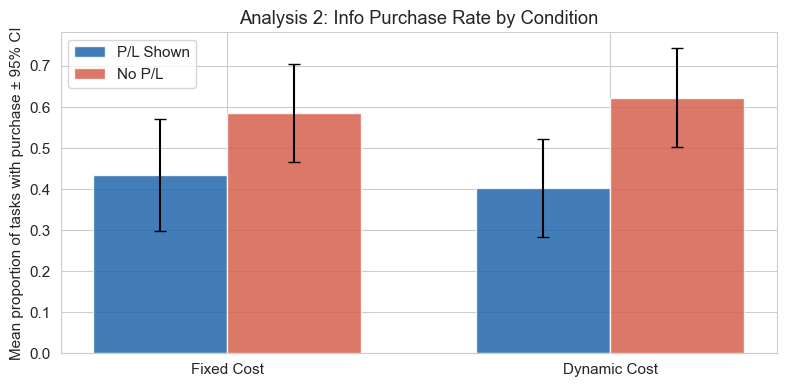

In [8]:
# 2.2 Binomial regression: n_tasks_purchased ~ info_type * show_pl
# The outcome is a bounded count (0–10 tasks per participant); Binomial is correct.
# Poisson/NB assume unbounded support and conflate ceiling effects with overdispersion.
print('=== 2.2 Binomial regression on n_tasks_purchased (bounded: n_trials=10) ===\n')

df_info = df_info.copy()
df_info['n_tasks_purchased'] = (df_info['prop_tasks_purchased'] * 10).round().astype(int)

# Binomial GLM: pass (successes, failures) as 2-column endog — canonical form
# for a bounded count with known number of trials.
from patsy import dmatrix as _dmatrix

y_binom = np.column_stack([
    df_info['n_tasks_purchased'].values,
    (10 - df_info['n_tasks_purchased']).values
])
X_binom = _dmatrix(
    'C(info_type) + C(show_pl) + C(info_type):C(show_pl)',
    data=df_info, return_type='dataframe'
)
model_binom = sm.GLM(y_binom, X_binom, family=sm.families.Binomial()).fit()
print(model_binom.summary().tables[1])

# Pearson dispersion: ≈1.0 means Binomial adequate; >1.5 means individual
# heterogeneity in purchase propensity exceeds what Binomial assumes.
disp_binom = model_binom.pearson_chi2 / model_binom.df_resid
print(f'\nBinomial Pearson dispersion: {disp_binom:.3f}')
if disp_binom > 1.5:
    se_inflation = np.sqrt(disp_binom)
    print(f'Residual overdispersion — quasi-Binomial SE inflation: x{se_inflation:.3f}')
    print('Individual differences in purchase propensity exceed Binomial variance.')
    # Quasi-Binomial: inflate SEs, recompute z and p for honest reporting
    from scipy.stats import norm as _norm
    qb_se = model_binom.bse * se_inflation
    qb_z  = model_binom.params / qb_se
    qb_p  = 2 * (1 - _norm.cdf(np.abs(qb_z)))
    qb_ci_lo = model_binom.params - 1.96 * qb_se
    qb_ci_hi = model_binom.params + 1.96 * qb_se
    print('\nQuasi-Binomial adjusted results (honest SEs — use these for reporting):')
    qb_out = pd.DataFrame({
        'OR':       np.exp(model_binom.params),
        'adj_z':    qb_z.round(3),
        'adj_p':    qb_p.round(4),
        'CI_lower': np.exp(qb_ci_lo),
        'CI_upper': np.exp(qb_ci_hi)
    }).round(4)
    print(qb_out)
else:
    print('Binomial model adequate — no excess overdispersion.')

# Odds ratios
coef_b = model_binom.params
ci_b   = model_binom.conf_int()
print('\nOdds Ratios (Binomial):')
or_binom = pd.DataFrame({
    'OR':       np.exp(coef_b),
    'CI_lower': np.exp(ci_b[0]),
    'CI_upper': np.exp(ci_b[1]),
    'p':        model_binom.pvalues
}).round(4)
print(or_binom)

# Visualization: purchase rate bar chart
fig, ax = plt.subplots(figsize=(8, 4))
rate_df = df_info.groupby(['info_type', 'show_pl'])['prop_tasks_purchased'].agg(['mean', 'sem']).reset_index()
rate_df['ci95'] = rate_df['sem'] * 1.96
x = np.arange(2)
w = 0.35
for pl_val, label, offset, color in [
    (True,  'P/L Shown', -w/2, '#2166AC'),
    (False, 'No P/L',     w/2, '#D6604D')
]:
    sub = rate_df[rate_df['show_pl'] == pl_val].set_index('info_type').reindex(['fixed_cost', 'dynamic_cost'])
    ax.bar(x + offset, sub['mean'], w, yerr=sub['ci95'], label=label,
           color=color, capsize=4, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['Fixed Cost', 'Dynamic Cost'])
ax.set_ylabel('Mean proportion of tasks with purchase ± 95% CI')
ax.set_title('Analysis 2: Info Purchase Rate by Condition')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Full task dataset: tr (built in ex-09) has tasks 1-10 for all eligible participants,
# with stock_risk, condition labels (info_type, show_pl), confidence/risk ratings,
# lagged P&L, and purchased_info already merged.
df_mixed = tr.copy()
# Log-transform investment for mixed ANOVA (raw investment is right-skewed;
# consistent with the log1p transformation used in Analysis 7 LMM)
df_mixed['log_investment'] = np.log1p(df_mixed['total_investment'])

print(f'Mixed ANOVA dataset: {len(df_mixed)} rows')
print(f'Participants: {df_mixed["participant_id"].nunique()}, Tasks: {df_mixed["task_id"].nunique()}')

Mixed ANOVA dataset: 2230 rows
Participants: 223, Tasks: 10


In [10]:
# ─── Analysis 1: Mixed ANOVA (3 × 2 × 10) ──────────────────────────────────────
#
# Design: 3 (info_type, between) × 2 (show_pl, between) × 10 (task_id, within)
#
# pingouin.mixed_anova supports only ONE between-subjects factor. The full
# 3×2×10 design is addressed through three complementary steps:
#
#   [A] 6-condition omnibus: combine info_type × show_pl into a 6-level factor.
#       cond6 × task_id is an omnibus test capturing all two-way and three-way
#       trajectory patterns together.
#
#   [B] Marginal decomposition: separate 2-factor models for interpretable
#       main effects and pairwise trajectory interactions (info_type × task and
#       show_pl × task). These models collapse over one between factor and are
#       used for effect sizes, not as the primary inference.
#
#   [C] Three-way interaction test: LMM treats task_id as a linear trend and
#       directly tests info_type × show_pl × task_id.
#
#   [D] Post-hoc pairwise task contrasts (Holm-corrected paired t-tests at
#       tasks 1, 5, 10) for any significant trajectory interaction found in [B].

df_mixed['cond6'] = (
    df_mixed['info_type'] + ':' +
    df_mixed['show_pl'].map({True: 'pl', False: 'nopl'})
)

MIXED_DVS = [
    ('log_investment',    'log(Investment+1)'),
    ('confidence_rating', 'Confidence Rating'),
    ('risk_rating',       'Risk Rating'),
]

for dv, dv_label in MIXED_DVS:
    sub = df_mixed[['participant_id', 'task_id', dv, 'info_type', 'show_pl', 'cond6']].dropna()
    print(f'\n{"=" * 65}\nMixed ANOVA: {dv_label}  (N={sub["participant_id"].nunique()})\n{"=" * 65}')

    # Sphericity check (Mauchly's test on the within-subjects factor)
    try:
        sph = pg.sphericity(data=sub, dv=dv, within='task_id', subject='participant_id')
        print(f'[Sphericity — Mauchly] W={sph.W:.4f}, chi2({sph.dof})={sph.chi2:.3f}, '
              f'p={sph.pval:.4f} → {"VIOLATED — GG correction applied" if not sph.spher else "met — no correction needed"}')
    except Exception as e:
        print(f'  [Sphericity] {e}')

    # [A] Full 6-condition omnibus
    try:
        aov_full = pg.mixed_anova(
            data=sub, dv=dv, within='task_id',
            between='cond6', subject='participant_id', correction='auto'
        )
        cols_f = [c for c in ['Source', 'F', 'p_unc', 'np2', 'eps'] if c in aov_full.columns]
        print('[A] 6-condition omnibus (cond6 × task_id):')
        print(aov_full[cols_f].round(4).to_string(index=False))
    except Exception as e:
        print(f'  [A] error: {e}')

    # [B] Marginal decomposition
    marginal_interactions = {}
    for factor in ['info_type', 'show_pl']:
        try:
            aov_m = pg.mixed_anova(
                data=sub, dv=dv, within='task_id',
                between=factor, subject='participant_id', correction='auto'
            )
            cols_m = [c for c in ['Source', 'F', 'p_unc', 'np2', 'eps'] if c in aov_m.columns]
            print(f'\n[B] Marginal — {factor} × task_id:')
            print(aov_m[cols_m].round(4).to_string(index=False))
            # Store interaction p-value for post-hoc decision.
            # pg.mixed_anova labels the interaction row "Interaction" (not by factor names).
            ix_row = aov_m[aov_m['Source'] == 'Interaction']
            if len(ix_row):
                marginal_interactions[factor] = ix_row['p_unc'].values[0]
        except Exception as e:
            print(f'  [B] {factor} error: {e}')

    # [C] Three-way interaction via LMM (task_id as linear trend)
    try:
        lmm_3way = smf.mixedlm(
            f'{dv} ~ C(info_type) * C(show_pl) * task_id',
            data=sub, groups=sub['participant_id']
        ).fit(reml=True, method='lbfgs')
        three_way_terms = [p for p in lmm_3way.params.index
                           if 'info_type' in p and 'show_pl' in p and 'task_id' in p]
        if three_way_terms:
            print('\n[C] Three-way interaction (LMM, task as linear trend):')
            for k in three_way_terms:
                print(f'  {k}: beta={lmm_3way.params[k]:.4f}, p={lmm_3way.pvalues[k]:.4f}')
        else:
            print('\n[C] No three-way interaction terms found in LMM (check formula parsing)')
    except Exception as e:
        print(f'  [C] LMM three-way error: {e}')

    # [D] Post-hoc paired task contrasts for significant trajectory interactions
    for factor, p_ix in marginal_interactions.items():
        if p_ix >= 0.05:
            continue
        print(f'\n[D] Post-hoc task contrasts — {factor} × task_id (p={p_ix:.4f}):')
        print('    Paired t-tests at task pairs 1→5, 1→10, 5→10 within each level (Holm):')
        task_pairs = [(1, 5), (1, 10), (5, 10)]
        posthoc_rows = []
        for lv in sorted(sub[factor].unique()):
            grp_wide = (
                sub[sub[factor] == lv]
                .pivot_table(index='participant_id', columns='task_id', values=dv)
            )
            for t1, t2 in task_pairs:
                if t1 not in grp_wide.columns or t2 not in grp_wide.columns:
                    continue
                paired = grp_wide[[t1, t2]].dropna()
                if len(paired) < 3:
                    continue
                t_stat, p_raw = stats.ttest_rel(paired[t1], paired[t2])
                d_val = pg.compute_effsize(paired[t1], paired[t2], eftype='cohen')
                posthoc_rows.append({
                    factor: lv, 'task_A': t1, 'task_B': t2,
                    'mean_A': round(paired[t1].mean(), 3),
                    'mean_B': round(paired[t2].mean(), 3),
                    't': round(t_stat, 3), 'p_raw': round(p_raw, 4),
                    'd': round(d_val, 3)
                })
        if posthoc_rows:
            ph_df = pd.DataFrame(posthoc_rows)
            _, p_holm, _, _ = multipletests(ph_df['p_raw'], method='holm')
            ph_df['p_holm'] = p_holm.round(4)
            print(ph_df.to_string(index=False))



Mixed ANOVA: log(Investment+1)  (N=223)
[Sphericity — Mauchly] W=0.6597, chi2(44)=91.010, p=0.0000 → VIOLATED — GG correction applied


[A] 6-condition omnibus (cond6 × task_id):
     Source      F  p_unc    np2  eps
      cond6 1.3634 0.2392 0.0305  NaN
    task_id 7.7573 0.0000 0.0345 0.91
Interaction 1.0932 0.3116 0.0246  NaN

[B] Marginal — info_type × task_id:
     Source      F  p_unc    np2  eps
  info_type 3.1839 0.0433 0.0281  NaN
    task_id 7.7290 0.0000 0.0339 0.91
Interaction 0.8271 0.6694 0.0075  NaN

[B] Marginal — show_pl × task_id:
     Source      F  p_unc    np2  eps
    show_pl 0.1511 0.6979 0.0007  NaN
    task_id 7.7334 0.0000 0.0338 0.91
Interaction 0.7813 0.6338 0.0035  NaN



[C] Three-way interaction (LMM, task as linear trend):
  C(info_type)[T.fixed_cost]:C(show_pl)[T.True]:task_id: beta=0.1904, p=0.0079
  C(info_type)[T.none]:C(show_pl)[T.True]:task_id: beta=0.1406, p=0.0505

Mixed ANOVA: Confidence Rating  (N=223)
[Sphericity — Mauchly] W=0.2593, chi2(44)=295.362, p=0.0000 → VIOLATED — GG correction applied
[A] 6-condition omnibus (cond6 × task_id):
     Source      F  p_unc    np2    eps
      cond6 2.0464 0.0734 0.0450    NaN
    task_id 1.4093 0.1783 0.0065 0.7071
Interaction 2.3260 0.0000 0.0509    NaN

[B] Marginal — info_type × task_id:
     Source      F  p_unc    np2    eps
  info_type 0.4771 0.6212 0.0043    NaN
    task_id 1.3806 0.1913 0.0062 0.7071
Interaction 1.9829 0.0081 0.0177    NaN

[B] Marginal — show_pl × task_id:
     Source      F  p_unc    np2    eps
    show_pl 6.9324 0.0091 0.0304    NaN
    task_id 1.3967 0.1839 0.0063 0.7071
Interaction 5.5764 0.0000 0.0246    NaN

[C] Three-way interaction (LMM, task as linear trend):
  C(i

   info_type  task_A  task_B  mean_A  mean_B      t  p_raw      d  p_holm
dynamic_cost       1       5  62.750  57.461  2.049 0.0439  0.235  0.3512
dynamic_cost       1      10  62.750  55.737  2.446 0.0168  0.304  0.1512
dynamic_cost       5      10  57.461  55.737  0.756 0.4522  0.072  1.0000
  fixed_cost       1       5  57.378  56.743  0.252 0.8017  0.027  1.0000
  fixed_cost       1      10  57.378  54.486  0.968 0.3362  0.120  1.0000
  fixed_cost       5      10  56.743  54.486  1.132 0.2612  0.099  1.0000
        none       1       5  51.671  56.493 -1.777 0.0799 -0.186  0.5593
        none       1      10  51.671  54.863 -1.036 0.3037 -0.125  1.0000
        none       5      10  56.493  54.863  0.630 0.5308  0.067  1.0000

[D] Post-hoc task contrasts — show_pl × task_id (p=0.0000):
    Paired t-tests at task pairs 1→5, 1→10, 5→10 within each level (Holm):
 show_pl  task_A  task_B  mean_A  mean_B      t  p_raw      d  p_holm
   False       1       5  56.469  59.903 -2.052 0.0425


[C] Three-way interaction (LMM, task as linear trend):
  C(info_type)[T.fixed_cost]:C(show_pl)[T.True]:task_id: beta=0.4130, p=0.5154
  C(info_type)[T.none]:C(show_pl)[T.True]:task_id: beta=0.6582, p=0.3015


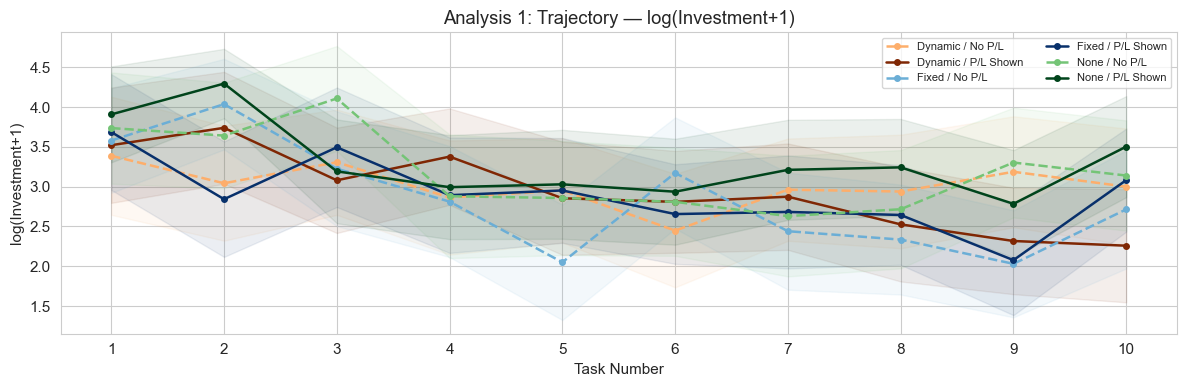

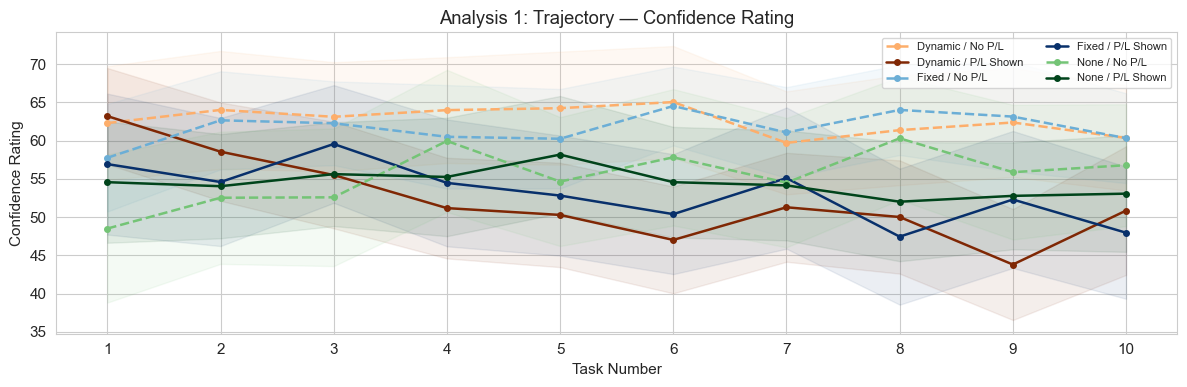

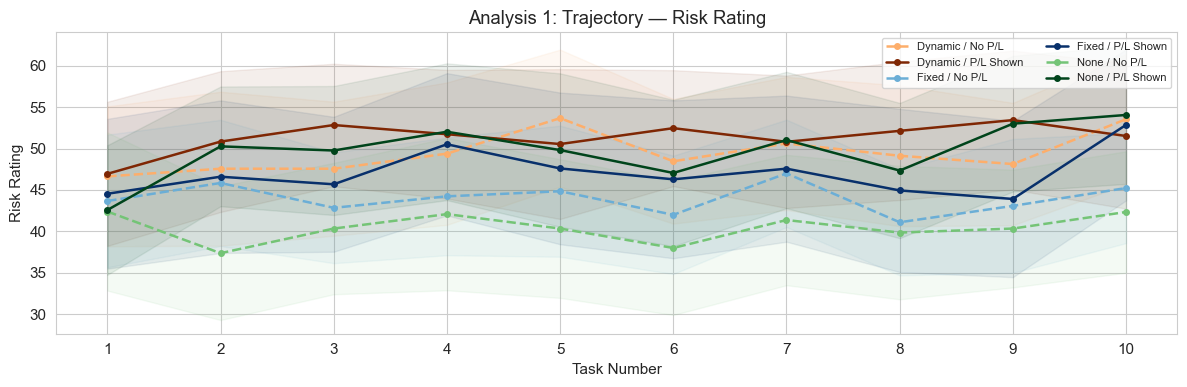

In [11]:
# Trajectory visualization: mean DV per task, separate lines per condition.
# Investment plotted on log(Investment+1) scale to match the mixed ANOVA DV —
# raw-scale plots would be visually inconsistent with the statistical test.
for dv, ylabel in [
    ('log_investment',    'log(Investment+1)'),
    ('confidence_rating', 'Confidence Rating'),
    ('risk_rating',       'Risk Rating'),
]:
    traj = df_mixed.groupby(['task_id', 'info_type', 'show_pl'])[dv].agg(['mean', 'sem']).reset_index()
    traj['ci95'] = traj['sem'] * 1.96

    fig, ax = plt.subplots(figsize=(12, 4))
    palette = {
        ('fixed_cost',   True):  '#08306B',
        ('fixed_cost',   False): '#6BAED6',
        ('dynamic_cost', True):  '#7F2704',
        ('dynamic_cost', False): '#FDAE6B',
        ('none',         True):  '#00441B',
        ('none',         False): '#74C476'
    }
    labels = {
        ('fixed_cost',   True):  'Fixed / P/L Shown',
        ('fixed_cost',   False): 'Fixed / No P/L',
        ('dynamic_cost', True):  'Dynamic / P/L Shown',
        ('dynamic_cost', False): 'Dynamic / No P/L',
        ('none',         True):  'None / P/L Shown',
        ('none',         False): 'None / No P/L'
    }
    for (it, pl), grp in traj.groupby(['info_type', 'show_pl']):
        key = (it, pl)
        ls = '-' if pl else '--'
        ax.plot(grp['task_id'], grp['mean'], ls, color=palette[key],
                label=labels[key], linewidth=1.8, marker='o', markersize=4)
        ax.fill_between(grp['task_id'],
                        grp['mean'] - grp['ci95'],
                        grp['mean'] + grp['ci95'],
                        alpha=0.08, color=palette[key])
    ax.set_xlabel('Task Number')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Analysis 1: Trajectory — {ylabel}')
    ax.legend(fontsize=8, ncol=2, loc='upper right')
    ax.set_xticks(range(1, 11))
    plt.tight_layout()
    plt.show()

In [12]:
# Prepare lagged dataset
df_lag = df_task.dropna(subset=['prev_profit_loss', 'is_risky']).copy()
df_lag['log_investment'] = np.log1p(df_lag['total_investment'])
df_lag['show_pl_int'] = df_lag['show_pl'].astype(int)  # GEE needs numeric

print(f'Lagged dataset: {len(df_lag)} rows, {df_lag["participant_id"].nunique()} participants')
print(f'Investment rate: {df_lag["invested"].mean():.3f}')
print(f'prev_profit_loss range: [{df_lag["prev_profit_loss"].min():.1f}, {df_lag["prev_profit_loss"].max():.1f}]')

Lagged dataset: 2007 rows, 223 participants
Investment rate: 0.699
prev_profit_loss range: [-85.0, 166.7]


In [13]:
# 7a: GEE logistic — DV = invested (binary)
# Primary: exchangeable working correlation (natural structure for within-person
# clustering across 10 tasks). GEE is robust to misspecification via the sandwich
# estimator, but exchangeable is more efficient than independence for correlated data.
print('=== 7a: GEE logistic — invested (binary) ===\n')

model_invested = GEE.from_formula(
    'invested ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
    groups='participant_id',
    data=df_lag,
    family=Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()
).fit()
print(model_invested.summary().tables[1])

# AR(1) sensitivity check — nearby tasks should correlate more than distant ones
try:
    model_invested_ar1 = GEE.from_formula(
        'invested ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
        groups='participant_id',
        data=df_lag,
        family=Binomial(),
        cov_struct=sm.cov_struct.Autoregressive()
    ).fit()
    key_coef = 'prev_profit_loss:C(show_pl)[T.True]'
    if key_coef in model_invested_ar1.params.index:
        print(f'AR(1) sensitivity — interaction coef: {model_invested_ar1.params[key_coef]:.4f}, '
              f'p={model_invested_ar1.pvalues[key_coef]:.4f} '
              f'(exchangeable: {model_invested.params[key_coef]:.4f}, p={model_invested.pvalues[key_coef]:.4f})')
except Exception as e:
    print(f'AR(1) model did not converge: {e}')

# Odds ratios
print('\nOdds Ratios (exp(coef)) and 95% CI:')
coef = model_invested.params
ci   = model_invested.conf_int()
or_df = pd.DataFrame({
    'OR': np.exp(coef),
    'CI_lower': np.exp(ci[0]),
    'CI_upper': np.exp(ci[1]),
    'p': model_invested.pvalues
}).round(4)
print(or_df)

=== 7a: GEE logistic — invested (binary) ===

                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               1.3103      0.190      6.887      0.000       0.937       1.683
C(show_pl)[T.True]                      0.3312      0.161      2.051      0.040       0.015       0.648
C(info_type)[T.fixed_cost]             -0.1049      0.189     -0.554      0.580      -0.476       0.266
C(info_type)[T.none]                    0.2703      0.202      1.341      0.180      -0.125       0.666
prev_profit_loss                        0.0051      0.005      1.024      0.306      -0.005       0.015
prev_profit_loss:C(show_pl)[T.True] -3.446e-05      0.007     -0.005      0.996      -0.014       0.014
is_risky                               -0.5154      0.101     -5.119      0.000      -0.713      -0.318
task_id           

AR(1) sensitivity — interaction coef: 0.0016, p=0.8113 (exchangeable: -0.0000, p=0.9962)

Odds Ratios (exp(coef)) and 95% CI:
                                         OR  CI_lower  CI_upper       p
Intercept                            3.7074    2.5533    5.3830  0.0000
C(show_pl)[T.True]                   1.3926    1.0149    1.9110  0.0402
C(info_type)[T.fixed_cost]           0.9005    0.6213    1.3049  0.5796
C(info_type)[T.none]                 1.3104    0.8826    1.9455  0.1800
prev_profit_loss                     1.0051    0.9954    1.0149  0.3058
prev_profit_loss:C(show_pl)[T.True]  1.0000    0.9860    1.0142  0.9962
is_risky                             0.5972    0.4903    0.7276  0.0000
task_id                              0.9359    0.9019    0.9711  0.0004


In [14]:
# 7b: Linear Mixed Model — DV = log(total_investment + 1)
print('=== 7b: LMM — log(total_investment + 1) ===\n')

model_investment = smf.mixedlm(
    'log_investment ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
    data=df_lag,
    groups=df_lag['participant_id']
).fit(reml=True)
print(model_investment.summary().tables[1])

=== 7b: LMM — log(total_investment + 1) ===

                                      Coef. Std.Err.       z  P>|z|  [0.025  \
Intercept                             3.803    0.173  22.016  0.000   3.465   
C(show_pl)[T.True]                    0.026    0.135   0.190  0.849  -0.238   
C(info_type)[T.fixed_cost]           -0.140    0.164  -0.855  0.393  -0.462   
C(info_type)[T.none]                  0.253    0.165   1.535  0.125  -0.070   
prev_profit_loss                      0.008    0.005   1.787  0.074  -0.001   
prev_profit_loss:C(show_pl)[T.True]  -0.005    0.006  -0.765  0.444  -0.018   
is_risky                             -0.711    0.088  -8.095  0.000  -0.883   
task_id                              -0.090    0.017  -5.294  0.000  -0.123   
Group Var                             0.583    0.052                          

                                     0.975]  
Intercept                             4.142  
C(show_pl)[T.True]                    0.290  
C(info_type)[T.fixed_cost]

In [15]:
# 7c: GEE logistic — DV = purchased_info (info-available conditions only)
# Primary: exchangeable working correlation; AR(1) as sensitivity check.
print('=== 7c: GEE logistic — purchased_info (e1, e2, e4, e5 only) ===\n')

df_info_lag = df_lag[
    df_lag['info_type'].isin(['fixed_cost', 'dynamic_cost'])
].dropna(subset=['purchased_info']).copy()

print(f'Info-available lagged rows: {len(df_info_lag)}')
print(f'Purchase rate: {df_info_lag["purchased_info"].mean():.3f}')

model_purchase = GEE.from_formula(
    'purchased_info ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
    groups='participant_id',
    data=df_info_lag,
    family=Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()
).fit()
print(model_purchase.summary().tables[1])

# AR(1) sensitivity check
try:
    model_purchase_ar1 = GEE.from_formula(
        'purchased_info ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
        groups='participant_id',
        data=df_info_lag,
        family=Binomial(),
        cov_struct=sm.cov_struct.Autoregressive()
    ).fit()
    key_coef = 'prev_profit_loss:C(show_pl)[T.True]'
    if key_coef in model_purchase_ar1.params.index:
        print(f'AR(1) sensitivity — interaction coef: {model_purchase_ar1.params[key_coef]:.4f}, '
              f'p={model_purchase_ar1.pvalues[key_coef]:.4f} '
              f'(exchangeable: {model_purchase.params[key_coef]:.4f}, p={model_purchase.pvalues[key_coef]:.4f})')
except Exception as e:
    print(f'AR(1) model did not converge: {e}')

print('\nOdds Ratios:')
coef = model_purchase.params
ci   = model_purchase.conf_int()
or_df = pd.DataFrame({
    'OR': np.exp(coef),
    'CI_lower': np.exp(ci[0]),
    'CI_upper': np.exp(ci[1]),
    'p': model_purchase.pvalues
}).round(4)
print(or_df)

=== 7c: GEE logistic — purchased_info (e1, e2, e4, e5 only) ===

Info-available lagged rows: 1350
Purchase rate: 0.500


                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               0.8750      0.266      3.294      0.001       0.354       1.396
C(show_pl)[T.True]                     -0.7579      0.270     -2.812      0.005      -1.286      -0.230
C(info_type)[T.fixed_cost]             -0.0175      0.270     -0.065      0.948      -0.546       0.511
prev_profit_loss                       -0.0016      0.004     -0.369      0.712      -0.010       0.007
prev_profit_loss:C(show_pl)[T.True]     0.0036      0.005      0.686      0.493      -0.007       0.014
is_risky                               -0.1234      0.081     -1.531      0.126      -0.281       0.035
task_id                                -0.0726      0.018     -3.931      0.000      -0.109      -0.036
AR(1) model did not converge: Autoregressive: unable to find rig

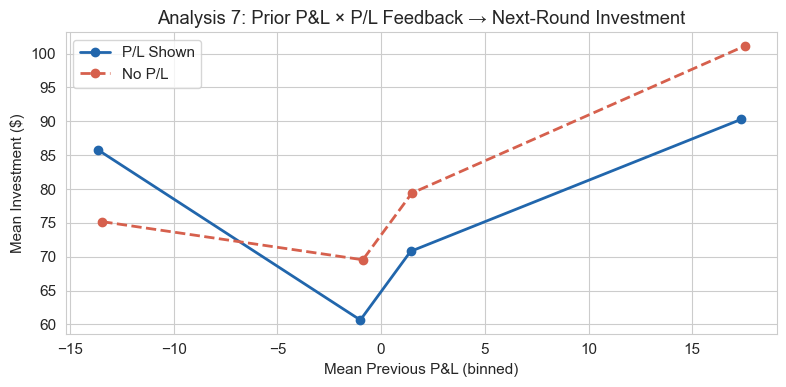

In [16]:
# 7d: Interaction plot — prev_profit_loss × show_pl on investment
# Bin prev_profit_loss into quintiles for visualization
df_lag['pl_bin'] = pd.qcut(df_lag['prev_profit_loss'], q=5, labels=False, duplicates='drop')
bin_means = df_lag.groupby(['pl_bin', 'show_pl'])[['prev_profit_loss', 'total_investment']].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
for pl_val, label, color, ls in [
    (True, 'P/L Shown', '#2166AC', '-'),
    (False, 'No P/L', '#D6604D', '--')
]:
    sub = bin_means[bin_means['show_pl'] == pl_val]
    ax.plot(sub['prev_profit_loss'], sub['total_investment'],
            ls, color=color, label=label, linewidth=2, marker='o', markersize=6)
ax.set_xlabel('Mean Previous P&L (binned)')
ax.set_ylabel('Mean Investment ($)')
ax.set_title('Analysis 7: Prior P&L × P/L Feedback → Next-Round Investment')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# 7e: Quadratic P&L interaction — LMM (motivated by V-shaped pattern in 7d)
# Tests whether the feedback-modulated curvature (not just slope) of the P&L
# response explains the visual pattern. A significant prev_pl_sq × show_pl
# term motivates pre-registering the quadratic form in the confirmatory study.
print('=== 7e: Quadratic P&L interaction — LMM (log investment) ===\n')

df_lag['prev_pl_sq'] = df_lag['prev_profit_loss'] ** 2

model_quad = smf.mixedlm(
    'log_investment ~ prev_profit_loss * C(show_pl) + prev_pl_sq * C(show_pl)'
    ' + C(info_type) + is_risky + task_id',
    data=df_lag,
    groups=df_lag['participant_id']
).fit(reml=True)

print('Quadratic terms:')
for k in model_quad.params.index:
    if 'prev_pl_sq' in k:
        coef = model_quad.params[k]
        se   = model_quad.bse[k]
        p    = model_quad.pvalues[k]
        print(f'  {k}: coef={coef:.5f}, SE={se:.5f}, p={p:.4f},'
              f' 95% CI [{coef - 1.96*se:.5f}, {coef + 1.96*se:.5f}]')

# Model fit comparison — refit with ML (not REML) for valid AIC/BIC comparison.
# REML likelihoods condition on fixed effects and cannot be used to compare
# models that differ in their fixed-effects structure.
model_investment_ml = smf.mixedlm(
    'log_investment ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
    data=df_lag, groups=df_lag['participant_id']
).fit(reml=False)
model_quad_ml = smf.mixedlm(
    'log_investment ~ prev_profit_loss * C(show_pl) + prev_pl_sq * C(show_pl)'
    ' + C(info_type) + is_risky + task_id',
    data=df_lag, groups=df_lag['participant_id']
).fit(reml=False)
print(f'\nLinear (7b, ML):    AIC={model_investment_ml.aic:.1f}, BIC={model_investment_ml.bic:.1f}')
print(f'Quadratic (7e, ML): AIC={model_quad_ml.aic:.1f}, BIC={model_quad_ml.bic:.1f}')
delta_aic = model_quad_ml.aic - model_investment_ml.aic
print(f'\u0394AIC = {delta_aic:.1f}  (negative favours quadratic)')


=== 7e: Quadratic P&L interaction — LMM (log investment) ===



Quadratic terms:
  prev_pl_sq: coef=0.00017, SE=0.00008, p=0.0311, 95% CI [0.00002, 0.00032]
  prev_pl_sq:C(show_pl)[T.True]: coef=-0.00013, SE=0.00010, p=0.1885, 95% CI [-0.00033, 0.00007]



Linear (7b, ML):    AIC=8600.4, BIC=8656.4
Quadratic (7e, ML): AIC=8599.4, BIC=8666.7
ΔAIC = -0.9  (negative favours quadratic)


In [18]:
# Analysis 7: Sensitivity analysis — minimum detectable effect (MDE) for null interactions
# MDE = t_crit × SE of the fitted interaction coefficient (estimated from this dataset).
# t_crit ≈ 2.80 for α=.05 two-sided, 80% power.
print('=== Analysis 7: Sensitivity Analysis — Minimum Detectable Effects ===\n')
print('α=.05 two-sided, 80% power  →  t_crit ≈ 2.80')
print('MDE = t_crit × SE(interaction), where SE is estimated from the fitted model.\n')

from scipy.stats import norm as _norm
_t_crit = _norm.ppf(0.975) + _norm.ppf(0.80)  # ≈ 2.80

def _find_interaction_se(model):
    for k in model.params.index:
        if 'prev_profit_loss' in k and 'show_pl' in k:
            return k, float(model.bse[k])
    return None, None

# 7a: GEE logistic — invested
k7a, se7a = _find_interaction_se(model_invested)
if se7a:
    mde7a = _t_crit * se7a
    print(f'7a GEE (invested):')
    print(f'  Interaction term : {k7a}')
    print(f'  SE = {se7a:.4f}  →  MDE = {mde7a:.3f} log-odds, MDE OR = {np.exp(mde7a):.3f}')
    print(f'  Study powered to detect OR ≥ {np.exp(mde7a):.2f} at 80% power\n')

# 7b: LMM — log investment
k7b, se7b = _find_interaction_se(model_investment)
if se7b:
    mde7b = _t_crit * se7b
    print(f'7b LMM (log investment):')
    print(f'  Interaction term : {k7b}')
    print(f'  SE = {se7b:.4f}  →  MDE = {mde7b:.4f} log-$ per unit P&L')
    print(f'             ≈ {np.exp(mde7b) - 1:.1%} multiplicative per unit P&L\n')

# 7c: GEE logistic — purchased_info
k7c, se7c = _find_interaction_se(model_purchase)
if se7c:
    mde7c = _t_crit * se7c
    print(f'7c GEE (purchased_info):')
    print(f'  Interaction term : {k7c}')
    print(f'  SE = {se7c:.4f}  →  MDE = {mde7c:.3f} log-odds, MDE OR = {np.exp(mde7c):.3f}')
    print(f'  Study powered to detect OR ≥ {np.exp(mde7c):.2f} at 80% power\n')

print('All observed |z/t| values < 1.0 across 7a–7c — the nulls are not')
print('artefacts of insufficient power.')


=== Analysis 7: Sensitivity Analysis — Minimum Detectable Effects ===

α=.05 two-sided, 80% power  →  t_crit ≈ 2.80
MDE = t_crit × SE(interaction), where SE is estimated from the fitted model.

7a GEE (invested):
  Interaction term : prev_profit_loss:C(show_pl)[T.True]
  SE = 0.0072  →  MDE = 0.020 log-odds, MDE OR = 1.020
  Study powered to detect OR ≥ 1.02 at 80% power

7b LMM (log investment):
  Interaction term : prev_profit_loss:C(show_pl)[T.True]
  SE = 0.0065  →  MDE = 0.0182 log-$ per unit P&L
             ≈ 1.8% multiplicative per unit P&L

7c GEE (purchased_info):
  Interaction term : prev_profit_loss:C(show_pl)[T.True]
  SE = 0.0052  →  MDE = 0.015 log-odds, MDE OR = 1.015
  Study powered to detect OR ≥ 1.01 at 80% power

All observed |z/t| values < 1.0 across 7a–7c — the nulls are not
artefacts of insufficient power.


In [19]:
# Participant-level dataset for info-available conditions with aggregate DVs
# Rebuild aggregate DVs for this subset
df_workshop = (
    eligible[eligible['info_type'].isin(['fixed_cost', 'dynamic_cost'])]
    [['participant_id', 'experiment_key', 'info_type', 'show_pl',
      'ever_purchased', 'prop_tasks_purchased', 'mean_tabs_viewed']]
    .copy()
)

mean_inv = (
    task_responses[task_responses['participant_id'].isin(df_workshop['participant_id'])]
    .groupby('participant_id')['total_investment'].mean()
    .reset_index().rename(columns={'total_investment': 'mean_investment'})
)
mean_conf = (
    confidence_risk[confidence_risk['participant_id'].isin(df_workshop['participant_id'])]
    .groupby('participant_id')['confidence_rating'].mean()
    .reset_index().rename(columns={'confidence_rating': 'mean_confidence'})
)
mean_risk_agg = (
    confidence_risk[confidence_risk['participant_id'].isin(df_workshop['participant_id'])]
    .groupby('participant_id')['risk_rating'].mean()
    .reset_index().rename(columns={'risk_rating': 'mean_risk'})
)
df_workshop = df_workshop.merge(mean_inv, on='participant_id').merge(mean_conf, on='participant_id').merge(mean_risk_agg, on='participant_id')

print(f'Info-available N: {len(df_workshop)}')
print(f'Buyers: {df_workshop["ever_purchased"].sum()}, Non-buyers: {(df_workshop["ever_purchased"]==0).sum()}')

Info-available N: 150
Buyers: 115, Non-buyers: 35


In [20]:
# 4.1 Buyers vs non-buyers: Mann-Whitney U (investment) or t-test (confidence, risk)
# Done separately within each info_type to avoid confounding
print('=== 4.1 Buyers vs Non-buyers (within info_type) ===\n')

dv_tests = [
    ('mean_investment', 'Mann-Whitney U'),
    ('mean_confidence', 't-test'),
    ('mean_risk', 't-test')
]

for dv, test_type in dv_tests:
    print(f'--- {dv} ({test_type}) ---')
    for it in ['fixed_cost', 'dynamic_cost']:
        sub = df_workshop[df_workshop['info_type'] == it]
        buyers     = sub[sub['ever_purchased'] == 1][dv]
        non_buyers = sub[sub['ever_purchased'] == 0][dv]
        if len(buyers) < 2 or len(non_buyers) < 2:
            print(f'  {it}: insufficient data (buyers={len(buyers)}, non-buyers={len(non_buyers)})')
            continue
        if test_type == 'Mann-Whitney U':
            u, p = stats.mannwhitneyu(buyers, non_buyers, alternative='two-sided')
            r_rb = 1 - (2 * u) / (len(buyers) * len(non_buyers))
            print(f'  {it}: U={u:.1f}, p={p:.4f}, r_rb={r_rb:.3f} (n_buy={len(buyers)}, n_nonbuy={len(non_buyers)})')
        else:
            t, p = stats.ttest_ind(buyers, non_buyers, equal_var=False)
            d = pg.compute_effsize(buyers, non_buyers, eftype='cohen')
            print(f'  {it}: t={t:.3f}, p={p:.4f}, d={d:.3f} (n_buy={len(buyers)}, n_nonbuy={len(non_buyers)})')
    print()

=== 4.1 Buyers vs Non-buyers (within info_type) ===

--- mean_investment (Mann-Whitney U) ---
  fixed_cost: U=296.0, p=0.0030, r_rb=0.452 (n_buy=54, n_nonbuy=20)
  dynamic_cost: U=159.5, p=0.0001, r_rb=0.651 (n_buy=61, n_nonbuy=15)

--- mean_confidence (t-test) ---
  fixed_cost: t=-0.011, p=0.9912, d=-0.003 (n_buy=54, n_nonbuy=20)
  dynamic_cost: t=-0.047, p=0.9629, d=-0.010 (n_buy=61, n_nonbuy=15)

--- mean_risk (t-test) ---
  fixed_cost: t=-0.811, p=0.4241, d=-0.234 (n_buy=54, n_nonbuy=20)
  dynamic_cost: t=0.725, p=0.4763, d=0.209 (n_buy=61, n_nonbuy=15)



In [21]:
# 4.2 Depth of engagement: Spearman correlation between mean_tabs_viewed and DVs (buyers only)
print('=== 4.2 Depth of engagement (buyers only) ===\n')

buyers_only = df_workshop[df_workshop['ever_purchased'] == 1]
print(f'Buyers: {len(buyers_only)}')

for dv in ['mean_investment', 'mean_confidence', 'mean_risk']:
    corr = pg.corr(buyers_only['mean_tabs_viewed'], buyers_only[dv], method='spearman')
    r = corr['r'].values[0]
    p = corr['p-val'].values[0] if 'p-val' in corr.columns else corr['p_val'].values[0]
    ci = corr['CI95%'].values[0] if 'CI95%' in corr.columns else corr['CI95'].values[0]
    print(f'  tabs_viewed ~ {dv}: r_s={r:.3f}, p={p:.4f}, 95% CI [{ci[0]:.3f}, {ci[1]:.3f}]')

=== 4.2 Depth of engagement (buyers only) ===

Buyers: 115
  tabs_viewed ~ mean_investment: r_s=-0.245, p=0.0084, 95% CI [-0.410, -0.060]
  tabs_viewed ~ mean_confidence: r_s=-0.004, p=0.9678, 95% CI [-0.190, 0.180]
  tabs_viewed ~ mean_risk: r_s=-0.250, p=0.0071, 95% CI [-0.410, -0.070]


In [22]:
# 4.3 Purchased for chosen stock: Wilcoxon signed-rank on paired participant means
print('=== 4.3 Purchased for chosen stock ===\n')

# Task-level data for buyers in info conditions (tr contains all tasks 1-10)
df_buyers_tasks = tr[
    tr['participant_id'].isin(buyers_only['participant_id']) &
    tr['info_type'].isin(['fixed_cost', 'dynamic_cost'])
].copy()
df_buyers_tasks['purchased_for_chosen_stock'] = (
    df_buyers_tasks['purchased_for_chosen_stock'].fillna(0).astype(int)
)

buyer_means = (
    df_buyers_tasks.groupby(['participant_id', 'purchased_for_chosen_stock'])['total_investment']
    .mean()
    .unstack()
    .dropna()  # only buyers who have both matched and unmatched tasks
)

print(f'Buyers with both matched and unmatched tasks: {len(buyer_means)}')
if len(buyer_means) >= 5:
    stat, p = stats.wilcoxon(buyer_means[1], buyer_means[0])
    n = len(buyer_means)
    r_rb = 1 - (2 * stat) / (n * (n + 1) / 2)
    print(f'Wilcoxon signed-rank: W={stat:.1f}, p={p:.4f}')
    print(f'Mean investment — matched: {buyer_means[1].mean():.2f}, unmatched: {buyer_means[0].mean():.2f}')
    print(f'Rank-biserial effect size: r_rb={r_rb:.3f}')
else:
    print('Insufficient paired observations for Wilcoxon test')

=== 4.3 Purchased for chosen stock ===

Buyers with both matched and unmatched tasks: 83
Wilcoxon signed-rank: W=541.0, p=0.0000
Mean investment — matched: 117.14, unmatched: 43.11
Rank-biserial effect size: r_rb=0.690


In [23]:
# Encode experience ordinally
exp_map = {'none': 0, 'limited': 1, 'some': 2, 'moderate': 3, 'extensive': 4}

demog = demographics[demographics['participant_id'].isin(valid_ids)].copy()
if 'experience' in demog.columns:
    demog['experience_ord'] = demog['experience'].str.lower().map(exp_map)
else:
    print('experience column not found — check demographics.csv columns:')
    print(demog.columns.tolist())

print('Demographics columns:', demog.columns.tolist())
print(demog.head(2))

Demographics columns: ['id', 'participant_id', 'age_range', 'gender', 'gender_self_describe', 'hispanic_latino', 'race', 'race_other', 'education', 'employment', 'executive_shareholder', 'exchange_brokerage', 'income', 'experience', 'submitted_at', 'experience_ord']
   id                        participant_id age_range gender  \
0  43  1c94c15b-9966-4cbb-9525-d8a66a273f97     35-44   male   
2  45  5dcdd9a6-4c36-4906-9de2-f7d3aa4586e1     25-34   male   

   gender_self_describe hispanic_latino                    race race_other  \
0                   NaN             yes                   asian        NaN   
2                   NaN              no  black-african-american        NaN   

   education employment executive_shareholder exchange_brokerage  \
0  bachelors   employed                    no                 no   
2  bachelors   employed                    no                 no   

          income experience             submitted_at  experience_ord  
0  less-than-20k    limited  

In [24]:
# Build ANCOVA dataset: merge workshop aggregates with demographics
mean_inv_all = (
    task_responses[task_responses['participant_id'].isin(valid_ids)]
    .groupby('participant_id')['total_investment'].mean()
    .reset_index().rename(columns={'total_investment': 'mean_investment'})
)
mean_conf_all = (
    confidence_risk[confidence_risk['participant_id'].isin(valid_ids)]
    .groupby('participant_id')['confidence_rating'].mean()
    .reset_index().rename(columns={'confidence_rating': 'mean_confidence'})
)

df_ancova = (
    eligible[['participant_id', 'info_type', 'show_pl']]
    .merge(mean_inv_all, on='participant_id')
    .merge(mean_conf_all, on='participant_id')
    .merge(demog[['participant_id', 'experience_ord']], on='participant_id', how='left')
)

print(f'ANCOVA dataset: {len(df_ancova)} rows')
print(f'Missing experience: {df_ancova["experience_ord"].isna().sum()}')

# Check experience is not confounded with condition (should be random assignment)
print('\nOne-way ANOVA: experience ~ experiment_key (should be null):')
df_ancova_exp = df_ancova.merge(
    eligible[['participant_id', 'experiment_key']], on='participant_id', how='left'
)
aov_exp = pg.anova(data=df_ancova_exp.dropna(subset=['experience_ord']),
                   dv='experience_ord', between='experiment_key', detailed=False)
print(aov_exp[['Source', 'F', 'p_unc']].round(4).to_string(index=False))

ANCOVA dataset: 223 rows
Missing experience: 0

One-way ANOVA: experience ~ experiment_key (should be null):
        Source      F  p_unc
experiment_key 1.2682 0.2787


In [25]:
# ANCOVA: mean_confidence ~ info_type * show_pl + experience
print('=== ANCOVA: mean_confidence ~ info_type * show_pl + experience ===\n')

df_anc = df_ancova.dropna(subset=['experience_ord'])

# Homogeneity of regression slopes: experience effect should not differ by condition
model_slopes = ols(
    'mean_confidence ~ C(info_type) * C(show_pl) * experience_ord',
    data=df_anc
).fit()
slopes_table = sm.stats.anova_lm(model_slopes, typ=3)
exp_interaction_rows = [r for r in slopes_table.index
                        if 'experience' in r and ':' in r]
print('Homogeneity of regression slopes (interactions with experience should be n.s.):')
if exp_interaction_rows:
    print(slopes_table.loc[exp_interaction_rows, ['df', 'F', 'PR(>F)']].round(4).to_string())
else:
    print('  No interaction terms found in model')
print()

model_anc = ols(
    'mean_confidence ~ C(info_type) * C(show_pl) + experience_ord',
    data=df_anc
).fit()
ancova_table = sm.stats.anova_lm(model_anc, typ=3)
ss_r = ancova_table.loc['Residual', 'sum_sq']
ancova_table['partial_eta_sq'] = (ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ss_r)).round(4)
print(ancova_table[['df', 'F', 'PR(>F)', 'partial_eta_sq']].round(4).to_string())

print('\n--- Compare to unadjusted ANOVA (from workshop sensitivity check) ---')
model_unadj = ols('mean_confidence ~ C(info_type) * C(show_pl)', data=df_anc).fit()
aov_unadj = sm.stats.anova_lm(model_unadj, typ=3)
ss_r2 = aov_unadj.loc['Residual', 'sum_sq']
aov_unadj['partial_eta_sq'] = (aov_unadj['sum_sq'] / (aov_unadj['sum_sq'] + ss_r2)).round(4)
print(aov_unadj[['df', 'F', 'PR(>F)', 'partial_eta_sq']].round(4).to_string())

=== ANCOVA: mean_confidence ~ info_type * show_pl + experience ===

Homogeneity of regression slopes (interactions with experience should be n.s.):
                                         df       F  PR(>F)
C(info_type):experience_ord             2.0  1.4620  0.2341
C(show_pl):experience_ord               1.0  1.2934  0.2567
C(info_type):C(show_pl):experience_ord  2.0  1.7288  0.1800

                            df         F  PR(>F)  partial_eta_sq
Intercept                  1.0  240.3176  0.0000          0.5266
C(info_type)               2.0    1.8235  0.1639          0.0166
C(show_pl)                 1.0    6.1040  0.0143          0.0275
C(info_type):C(show_pl)    2.0    1.4050  0.2476          0.0128
experience_ord             1.0   11.3476  0.0009          0.0499
Residual                 216.0       NaN     NaN          0.5000

--- Compare to unadjusted ANOVA (from workshop sensitivity check) ---
                            df         F  PR(>F)  partial_eta_sq
Intercept           

In [26]:
# Build participant-level dataset with both aggregate DVs
df_corr = (
    eligible[['participant_id', 'info_type', 'show_pl', 'experiment_key']]
    .merge(mean_inv_all, on='participant_id')
    .merge(mean_conf_all, on='participant_id')
)
mean_risk_all = (
    confidence_risk[confidence_risk['participant_id'].isin(valid_ids)]
    .groupby('participant_id')['risk_rating'].mean()
    .reset_index().rename(columns={'risk_rating': 'mean_risk'})
)
df_corr = df_corr.merge(mean_risk_all, on='participant_id')

print('=== 6.1 Overall Spearman correlations ===\n')

for x_var, y_var in [
    ('mean_confidence', 'mean_investment'),
    ('mean_risk', 'mean_investment'),
    ('mean_confidence', 'mean_risk')
]:
    corr = pg.corr(df_corr[x_var], df_corr[y_var], method='spearman')
    r = corr['r'].values[0]
    p_col = 'p-val' if 'p-val' in corr.columns else 'p_val'
    ci_col = 'CI95%' if 'CI95%' in corr.columns else 'CI95'
    p = corr[p_col].values[0]
    ci = corr[ci_col].values[0]
    bf = corr['BF10'].values[0] if 'BF10' in corr.columns else 'N/A'
    print(f'  {x_var} ~ {y_var}: r_s={r:.3f}, p={p:.4f}, 95% CI [{ci[0]:.3f}, {ci[1]:.3f}], BF10={bf}')

# Bayesian evidence: Pearson BF10 (pg.corr only supports BF10 for Pearson)
# At n=223 participant-level means, CLT ensures approximate normality.
print('\n=== 6.1b Pearson BF\u2081\u2080 (supplementary Bayesian quantification) ===')
print('Note: BF10 unavailable for Spearman; Pearson used for Bayesian strength-of-evidence only.\n')
for x_var, y_var in [
    ('mean_confidence', 'mean_investment'),
    ('mean_risk',       'mean_investment'),
    ('mean_confidence', 'mean_risk')
]:
    corr_p = pg.corr(df_corr[x_var], df_corr[y_var], method='pearson')
    r_p   = corr_p['r'].values[0]
    p_col = 'p-val' if 'p-val' in corr_p.columns else 'p_val'
    p_p   = corr_p[p_col].values[0]
    bf    = corr_p['BF10'].values[0] if 'BF10' in corr_p.columns else 'unavailable'
    print(f'  {x_var} ~ {y_var}: r={r_p:.3f}, p={p_p:.4f}, BF₁₀={bf}')


=== 6.1 Overall Spearman correlations ===

  mean_confidence ~ mean_investment: r_s=0.055, p=0.4146, 95% CI [-0.080, 0.180], BF10=N/A
  mean_risk ~ mean_investment: r_s=0.166, p=0.0131, 95% CI [0.040, 0.290], BF10=N/A
  mean_confidence ~ mean_risk: r_s=-0.030, p=0.6539, 95% CI [-0.160, 0.100], BF10=N/A

=== 6.1b Pearson BF₁₀ (supplementary Bayesian quantification) ===
Note: BF10 unavailable for Spearman; Pearson used for Bayesian strength-of-evidence only.

  mean_confidence ~ mean_investment: r=0.117, p=0.0808, BF₁₀=0.381
  mean_risk ~ mean_investment: r=0.132, p=0.0487, BF₁₀=0.577
  mean_confidence ~ mean_risk: r=-0.045, p=0.5074, BF₁₀=0.104


In [27]:
# 6.2 Correlation by condition (6 cells)
print('=== 6.2 Confidence–Investment Spearman r by cell ===\n')

cell_corrs = []
for (it, pl), grp in df_corr.groupby(['info_type', 'show_pl']):
    if len(grp) < 5:
        continue
    corr = pg.corr(grp['mean_confidence'], grp['mean_investment'], method='spearman')
    r = corr['r'].values[0]
    p_col = 'p-val' if 'p-val' in corr.columns else 'p_val'
    p = corr[p_col].values[0]
    cell_corrs.append({'info_type': it, 'show_pl': pl, 'r_s': r, 'p': p, 'n': len(grp)})
    print(f'  {it} / P/L={pl}: r_s={r:.3f}, p={p:.4f}, n={len(grp)}')

# Fisher r-to-z comparison: info conditions with vs without P/L feedback
print('\nFisher r-to-z comparison (info conditions): P/L Shown vs No P/L')

def compare_correlations(r1, n1, r2, n2):
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)
    se = np.sqrt(1/(n1-3) + 1/(n2-3))
    z  = (z1 - z2) / se
    p  = 2 * (1 - norm.cdf(abs(z)))
    return z, p

from statsmodels.stats.multitest import multipletests as _mt

cc = pd.DataFrame(cell_corrs)
_conf_z_results = []
for it in ['fixed_cost', 'dynamic_cost', 'none']:
    row_true  = cc[(cc['info_type']==it) & (cc['show_pl']==True)]
    row_false = cc[(cc['info_type']==it) & (cc['show_pl']==False)]
    if len(row_true) and len(row_false):
        z, p = compare_correlations(
            row_true['r_s'].values[0], row_true['n'].values[0],
            row_false['r_s'].values[0], row_false['n'].values[0]
        )
        _conf_z_results.append((it, z, p))
        print(f'  {it}: z={z:.3f}, p={p:.4f}')
if _conf_z_results:
    _, p_adj, _, _ = _mt([r[2] for r in _conf_z_results], method='holm')
    print('  Holm-corrected p-values:', {r[0]: round(pa, 4) for r, pa in zip(_conf_z_results, p_adj)})

# 6.3 Risk–Investment Spearman r by condition
print('\n=== 6.3 Risk–Investment Spearman r by cell ===\n')

risk_corrs = []
for (it, pl), grp in df_corr.groupby(['info_type', 'show_pl']):
    if len(grp) < 5:
        continue
    corr = pg.corr(grp['mean_risk'], grp['mean_investment'], method='spearman')
    r = corr['r'].values[0]
    p_col = 'p-val' if 'p-val' in corr.columns else 'p_val'
    p = corr[p_col].values[0]
    risk_corrs.append({'info_type': it, 'show_pl': pl, 'r_s': r, 'p': p, 'n': len(grp)})
    print(f'  {it} / P/L={pl}: r_s={r:.3f}, p={p:.4f}, n={len(grp)}')

print('\nFisher r-to-z comparison (risk~investment): P/L Shown vs No P/L')
rc = pd.DataFrame(risk_corrs)
_risk_z_results = []
for it in ['fixed_cost', 'dynamic_cost', 'none']:
    row_true  = rc[(rc['info_type']==it) & (rc['show_pl']==True)]
    row_false = rc[(rc['info_type']==it) & (rc['show_pl']==False)]
    if len(row_true) and len(row_false):
        z, p = compare_correlations(
            row_true['r_s'].values[0], row_true['n'].values[0],
            row_false['r_s'].values[0], row_false['n'].values[0]
        )
        _risk_z_results.append((it, z, p))
        print(f'  {it}: z={z:.3f}, p={p:.4f}')
if _risk_z_results:
    _, p_adj, _, _ = _mt([r[2] for r in _risk_z_results], method='holm')
    print('  Holm-corrected p-values:', {r[0]: round(pa, 4) for r, pa in zip(_risk_z_results, p_adj)})

=== 6.2 Confidence–Investment Spearman r by cell ===

  dynamic_cost / P/L=False: r_s=0.197, p=0.2294, n=39
  dynamic_cost / P/L=True: r_s=-0.044, p=0.7978, n=37
  fixed_cost / P/L=False: r_s=-0.130, p=0.4317, n=39
  fixed_cost / P/L=True: r_s=-0.111, p=0.5274, n=35
  none / P/L=False: r_s=0.350, p=0.0394, n=35
  none / P/L=True: r_s=0.155, p=0.3528, n=38

Fisher r-to-z comparison (info conditions): P/L Shown vs No P/L
  fixed_cost: z=0.080, p=0.9365
  dynamic_cost: z=-1.017, p=0.3091
  none: z=-0.855, p=0.3928
  Holm-corrected p-values: {'fixed_cost': np.float64(0.9365), 'dynamic_cost': np.float64(0.9273), 'none': np.float64(0.9273)}

=== 6.3 Risk–Investment Spearman r by cell ===

  dynamic_cost / P/L=False: r_s=0.196, p=0.2309, n=39
  dynamic_cost / P/L=True: r_s=0.047, p=0.7814, n=37
  fixed_cost / P/L=False: r_s=0.378, p=0.0176, n=39
  fixed_cost / P/L=True: r_s=0.028, p=0.8753, n=35
  none / P/L=False: r_s=0.399, p=0.0176, n=35
  none / P/L=True: r_s=0.192, p=0.2489, n=38

Fisher

In [28]:
# Restrict to dynamic-cost conditions (e2, e5); tr contains all tasks 1-10
df_dyn = tr[
    tr['info_type'] == 'dynamic_cost'
].merge(
    all_tasks[['participant_id', 'task_id', 'info_cost_spent']],
    on=['participant_id', 'task_id'], how='left'
).copy()
# purchased_info already in tr from ex-09
df_dyn['purchased_info']  = df_dyn['purchased_info'].fillna(0).astype(int)
df_dyn['info_cost_spent'] = df_dyn['info_cost_spent'].fillna(0)

# Verify e2 and e5 have identical offered costs per ticker before merging.
# The merge below drops duplicates on stock_ticker; if costs differ across
# experiments, drop_duplicates silently keeps one and corrupts the merge.
_cost_parity = (
    info_costs[info_costs['experiment_key'].isin(['e2', 'e5'])]
    .groupby('stock_ticker')['cost_of_information']
    .nunique()
)
assert _cost_parity.max() == 1, (
    f"Cost mismatch between e2 and e5 for tickers: "
    f"{_cost_parity[_cost_parity > 1].index.tolist()}"
)
print('Cost parity check passed: e2 and e5 have identical costs per ticker.')

# Merge the OFFERED price (cost_of_information) from the design lookup table.
info_costs_dyn = (
    info_costs[info_costs['experiment_key'].isin(['e2', 'e5'])]
    [['stock_ticker', 'cost_of_information']]
    .drop_duplicates(subset='stock_ticker')
    .rename(columns={'stock_ticker': 'stock_1_ticker'})
)
df_dyn = df_dyn.merge(info_costs_dyn, on='stock_1_ticker', how='left')

print(f'Dynamic cost rows: {len(df_dyn)}')
print(f'Purchase rate: {df_dyn["purchased_info"].mean():.3f}')
print('Offered cost distribution (all tasks):')
print(df_dyn['cost_of_information'].value_counts().sort_index())
print('Purchase rate by offered cost:')
print(df_dyn.groupby('cost_of_information')['purchased_info'].agg(['mean','sum','count']).round(3))

Cost parity check passed: e2 and e5 have identical costs per ticker.
Dynamic cost rows: 760
Purchase rate: 0.516
Offered cost distribution (all tasks):
cost_of_information
3.0     228
5.0     228
8.0     228
12.0     76
Name: count, dtype: int64
Purchase rate by offered cost:
                      mean  sum  count
cost_of_information                   
3.0                  0.553  126    228
5.0                  0.504  115    228
8.0                  0.491  112    228
12.0                 0.513   39     76


In [29]:
# GEE logistic: purchased_info ~ cost_of_information + C(show_pl) + task_id
# Primary: exchangeable working correlation; AR(1) as sensitivity check.
# cost_of_information is the offered price per stock (varies by stock, not by
# purchase decision) — this is the correct predictor for price deterrence.
print('=== Analysis 3: GEE logistic — purchased_info ~ cost_of_information ===\n')

df_dyn_valid = df_dyn.dropna(subset=['cost_of_information'])

model_cost = GEE.from_formula(
    'purchased_info ~ cost_of_information + C(show_pl) + task_id',
    groups='participant_id',
    data=df_dyn_valid,
    family=Binomial(),
    cov_struct=sm.cov_struct.Exchangeable()
).fit()
print(model_cost.summary().tables[1])

print('\nOdds Ratios:')
coef = model_cost.params
ci   = model_cost.conf_int()
or_df = pd.DataFrame({
    'OR': np.exp(coef),
    'CI_lower': np.exp(ci[0]),
    'CI_upper': np.exp(ci[1]),
    'p': model_cost.pvalues
}).round(4)
print(or_df)

# AR(1) sensitivity check
try:
    model_cost_ar1 = GEE.from_formula(
        'purchased_info ~ cost_of_information + C(show_pl) + task_id',
        groups='participant_id',
        data=df_dyn_valid,
        family=Binomial(),
        cov_struct=sm.cov_struct.Autoregressive()
    ).fit()
    print(f'\nAR(1) sensitivity — cost coef: {model_cost_ar1.params["cost_of_information"]:.4f}, '
          f'p={model_cost_ar1.pvalues["cost_of_information"]:.4f} '
          f'(exchangeable: {model_cost.params["cost_of_information"]:.4f}, '
          f'p={model_cost.pvalues["cost_of_information"]:.4f})')
except Exception as e:
    print(f'AR(1) model did not converge: {e}')

# Fallback: task-level Spearman r between offered cost and purchase decision
print('\nFallback — Spearman r: cost_of_information ~ purchased_info (task level)')
corr = pg.corr(df_dyn_valid['cost_of_information'],
               df_dyn_valid['purchased_info'].astype(float), method='spearman')
p_col = 'p-val' if 'p-val' in corr.columns else 'p_val'
print(f'  r_s={corr["r"].values[0]:.3f}, p={corr[p_col].values[0]:.4f}')

=== Analysis 3: GEE logistic — purchased_info ~ cost_of_information ===



                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.3459      0.348      3.863      0.000       0.663       2.029
C(show_pl)[T.True]     -0.9327      0.379     -2.462      0.014      -1.675      -0.190
cost_of_information    -0.0267      0.021     -1.281      0.200      -0.068       0.014
task_id                -0.1124      0.026     -4.323      0.000      -0.163      -0.061



Odds Ratios:
                         OR  CI_lower  CI_upper       p
Intercept            3.8415    1.9405    7.6048  0.0001
C(show_pl)[T.True]   0.3935    0.1872    0.8269  0.0138
cost_of_information  0.9736    0.9346    1.0143  0.2001
task_id              0.8937    0.8493    0.9404  0.0000



AR(1) sensitivity — cost coef: -0.0288, p=0.2114 (exchangeable: -0.0267, p=0.2001)

Fallback — Spearman r: cost_of_information ~ purchased_info (task level)
  r_s=-0.041, p=0.2597
